<a href="https://colab.research.google.com/github/anshugupta27/Attention-Based-Stock-Prediction/blob/main/Anshu_Gupta_Stock_price_prediction_using_attention_based_hybrid_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import yfinance as yf

data = yf.download("AAPL", start="2022-01-01", end="2025-01-01")
data = data[['Close']]
data.dropna(inplace=True)


/tmp/ipython-input-27-3702665207.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2022-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [28]:
print(data)

Price            Close
Ticker            AAPL
Date                  
2022-01-03  178.645645
2022-01-04  176.378357
2022-01-05  171.686691
2022-01-06  168.820694
2022-01-07  168.987534
...                ...
2024-12-24  257.578674
2024-12-26  258.396667
2024-12-27  254.974930
2024-12-30  251.593094
2024-12-31  249.817383

[753 rows x 1 columns]


In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X, y = create_sequences(scaled_data, window_size)

X = X.reshape((X.shape[0], X.shape[1], 1))


In [30]:
print(X)
print(y)

[[[0.4091441 ]
  [0.39234631]
  [0.3575869 ]
  ...
  [0.3577515 ]
  [0.36415865]
  [0.38862317]]

 [[0.39234631]
  [0.3575869 ]
  [0.33635343]
  ...
  [0.36415865]
  [0.38862317]
  [0.37995855]]

 [[0.3575869 ]
  [0.33635343]
  [0.3375895 ]
  ...
  [0.38862317]
  [0.37995855]
  [0.35695044]]

 ...

 [[0.7598746 ]
  [0.75167959]
  [0.76002224]
  ...
  [0.9722842 ]
  [0.99393969]
  [1.        ]]

 [[0.75167959]
  [0.76002224]
  [0.7222961 ]
  ...
  [0.99393969]
  [1.        ]
  [0.97464918]]

 [[0.76002224]
  [0.7222961 ]
  [0.75241791]
  ...
  [1.        ]
  [0.97464918]
  [0.94959398]]]
[3.79958554e-01 3.56950440e-01 3.54766227e-01 3.84836943e-01
 3.60226929e-01 3.36709079e-01 3.38966209e-01 3.24039830e-01
 2.92440018e-01 3.06347150e-01 3.26297185e-01 2.89090839e-01
 2.87489166e-01 3.04453699e-01 3.03216155e-01 2.97318633e-01
 2.63607073e-01 2.71543540e-01 2.27274706e-01 2.25599777e-01
 2.77077159e-01 2.33463554e-01 2.35720570e-01 2.46787694e-01
 2.94406047e-01 2.27056183e-01 2.3245199

In [31]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Bidirectional, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

def build_model(input_shape):
    inp = Input(shape=input_shape)

    x = Conv1D(filters=64, kernel_size=3, activation='relu')(inp)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    # Attention Layer
    query = Dense(64)(x)
    value = Dense(64)(x)
    attention = Attention()([query, value])

    x = Concatenate()([x, attention])
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    output = Dense(1)(x)

    model = Model(inputs=inp, outputs=output)
    model.compile(optimizer='adam', loss='mse')

    return model

model = build_model((window_size, 1))
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 58, 64)    │        256 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 58, 128)   │     66,048 │ conv1d_2[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 58, 64)    │      8,256 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 58, 64)    │      8,256 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_2         │ (None, 58, 64)    │          0 │ dense_6[0][0],    │
│ (Attention)         │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 58, 192)   │          0 │ bidirectional_2[… │
│ (Concatenate)       │                   │            │ attention_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 192)       │          0 │ concatenate_2[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        193 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,009 (324.25 KB)

 Trainable params: 83,009 (324.25 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.0621
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.0103
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0078
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0080
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0085
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0087
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0072
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0080
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0074
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0080


In [33]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Use model to generate features
features = model.predict(X)

# Train XGBoost on those features
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2)
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

# Predict
predictions = xgb.predict(X_test)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


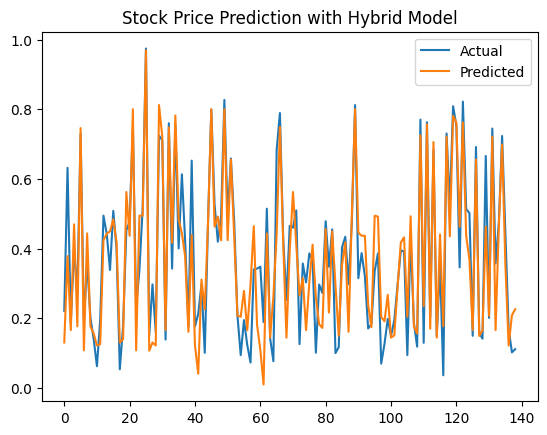

In [34]:
import matplotlib.pyplot as plt

plt.plot(y_test, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Stock Price Prediction with Hybrid Model")
plt.show()
